# Titanic Survival Prediction

# Importing Libraries



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Read the dataset

In [ ]:
train = pd.read_csv('/content/drive/MyDrive/data/Titanic_coursework_entire_dataset_23-24.csv')

In [ ]:
train.describe(include = "all")

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Survival
count,890.000000,888.000000,890,890,714.000000,890.000000,890.000000,890,890.000000,888,890.000000
unique,NaN,NaN,890,2,NaN,NaN,NaN,680,NaN,3,NaN
top,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,CA. 2343,NaN,S,NaN
freq,NaN,NaN,1,576,NaN,NaN,NaN,7,NaN,643,NaN
mean,445.500000,2.306306,NaN,NaN,29.699118,0.523596,0.382022,NaN,32.231521,NaN,0.384270
std,257.065167,0.836515,NaN,NaN,14.526497,1.103224,0.806409,NaN,49.714678,NaN,0.486696
min,1.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,0.000000
25%,223.250000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.925000,NaN,0.000000
50%,445.500000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,0.000000
75%,667.750000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,1.000000


In [ ]:
train.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Survival
0,1,3.0,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,0
1,2,1.0,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1
2,3,3.0,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1
3,4,1.0,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1
4,5,3.0,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0


## Categorical variables - PassengerId, Pclass, Name, Sex, Ticket, Embarked, and Survival
## Numerical variables -Age, SibSp, Parch, Fare


# Exploratory Data Analysis

# 1.Missing Data

In [ ]:
train.isnull()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Survival
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
885,False,False,False,False,False,False,False,False,False,False,False
886,False,False,False,False,False,False,False,False,False,False,False
887,False,False,False,False,True,False,False,False,False,False,False
888,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
# Check the column names in the DataFrame
print(train.columns)

# Check for missing values in the DataFrame
print(train.isnull().sum())

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Embarked', 'Survival'],
      dtype='object')
PassengerId      0
Pclass           2
Name             0
Sex              0
Age            176
SibSp            0
Parch            0
Ticket           0
Fare             0
Embarked         2
Survival         0
dtype: int64


<Axes: >

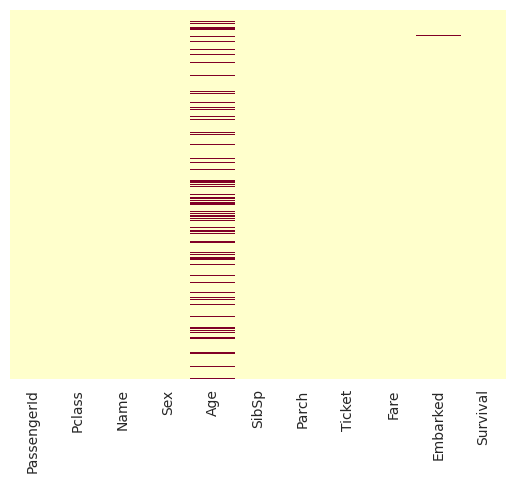

In [ ]:
sns.heatmap(train.isnull(),yticklabels=False,cbar=False,cmap='YlOrRd')

"0" typically indicates that the passenger did not survive.

"1" typically indicates that the passenger survived. **bold text**

<ipython-input-66-11f0cc1d09b7>:5: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




<Axes: xlabel='Survival', ylabel='count'>

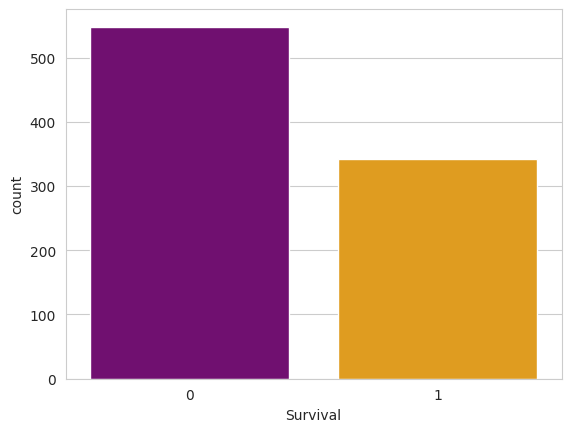

In [ ]:
# Set the aesthetic style of the plot
sns.set_style('whitegrid')

# Create the count plot with custom colors for each category
sns.countplot(x='Survival', data=train, palette={'0': 'purple', '1': 'orange'})


**It helps to quickly understand how survival rates differ between males and females.**






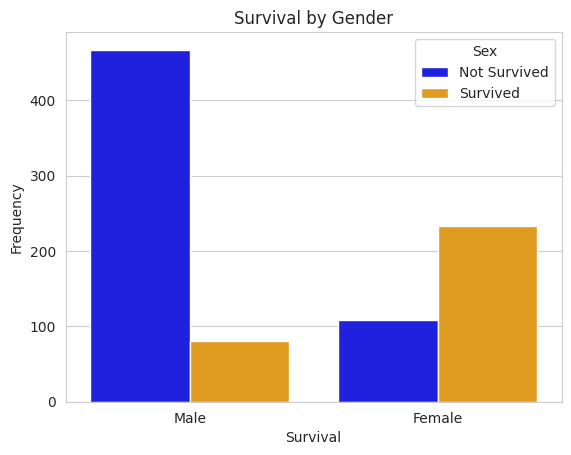

In [ ]:
# Gender by Survival
sns.set_style('whitegrid')
sns.countplot(x='Survival', hue='Sex', data=train, palette={'male': 'blue', 'female': 'orange'})

# Adding labels to the plot
plt.xlabel('Survival')
plt.ylabel('Frequency')
plt.title('Survival by Gender')
plt.legend(title='Sex', labels=['Not Survived', 'Survived'])
plt.xticks(ticks=[0, 1], labels=['Male', 'Female'])

plt.show()



**This picture helps you understand if more people from one class survived compared to others. For example, you might notice that more people from first class survived than from third class.**

<Axes: xlabel='Survival', ylabel='count'>

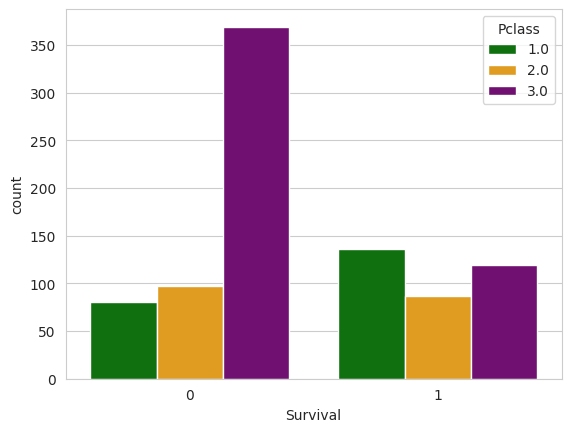

In [ ]:
# Set the aesthetic style to whitegrid
sns.set_style('whitegrid')

# Create the count plot
sns.countplot(x='Survival', hue='Pclass', data=train, palette=['green', 'orange', 'purple'])

# Age Distribution of Titanic Passengers

<ipython-input-11-29f62cf3882a>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train['Age'].dropna(), kde=False, color='navy', bins=40)


<Axes: xlabel='Age'>

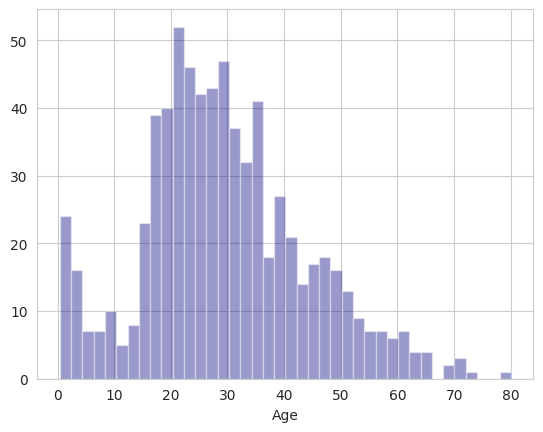

In [ ]:
sns.distplot(train['Age'].dropna(), kde=False, color='navy', bins=40)

<Axes: >

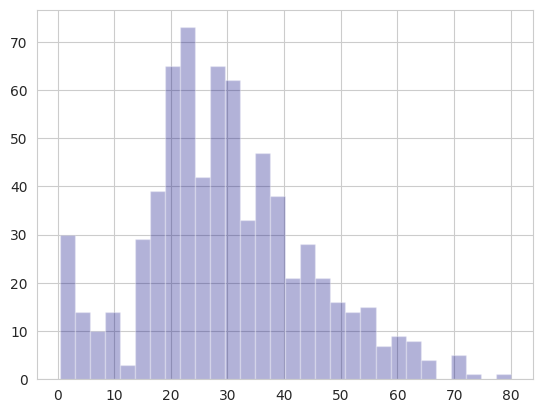

In [ ]:
train['Age'].hist(bins=30,color='navy',alpha=0.3)

**Count of Passengers by Number of Siblings/Spouses Aboard the Titanic**

<ipython-input-13-7ab82a3ee0a8>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='SibSp', data=train, palette='rainbow')


<Axes: xlabel='SibSp', ylabel='count'>

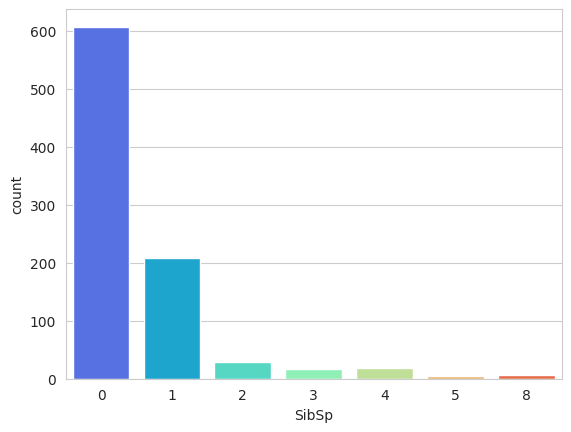

In [ ]:
sns.countplot(x='SibSp', data=train, palette='rainbow')


**Visualizing Ticket Prices of Titanic Passengers**



In [ ]:
# Survival rate of Gender based on Pclass with additional columns
gender_pclass_survival = train.groupby(['Pclass', 'Sex'])[['Age', 'SibSp', 'Parch', 'Fare', 'Survival']].mean().reset_index()
print(gender_pclass_survival)




   Pclass     Sex        Age     SibSp     Parch        Fare  Survival
0     1.0  female  34.611765  0.553191  0.457447  106.125798  0.968085
1     1.0    male  41.281386  0.311475  0.278689   67.226127  0.368852
2     2.0  female  28.722973  0.486842  0.605263   21.970121  0.921053
3     2.0    male  30.740707  0.342593  0.222222   19.741782  0.157407
4     3.0  female  21.750000  0.895833  0.798611   16.118810  0.500000
5     3.0    male  26.523586  0.502907  0.226744   12.659106  0.136628



# Age Distribution by Survival

<ipython-input-76-cfc4a4e402bd>:7: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




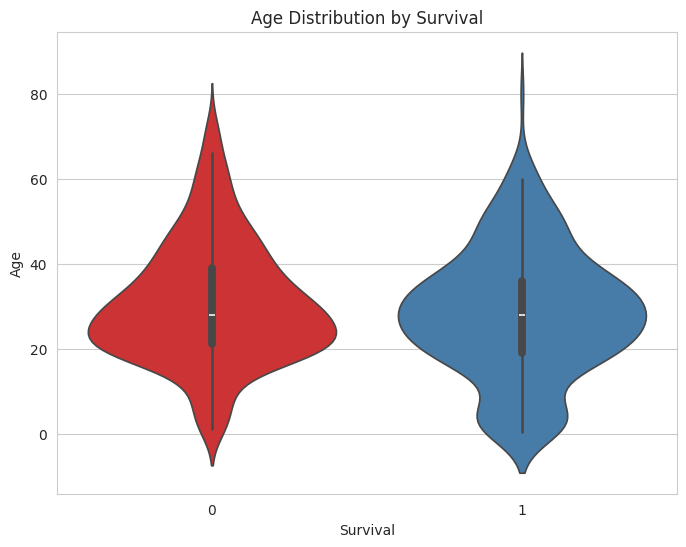

In [ ]:
import matplotlib.pyplot as plt

# Set up the figure and axis
plt.figure(figsize=(8, 6))

# Plot age by survival
sns.violinplot(x='Survival', y='Age', data=train, palette='Set1')

# Set the labels and title
plt.ylabel('Age')
plt.title('Age Distribution by Survival')

# Set the y-axis ticks
plt.yticks([0, 20, 40, 60, 80])

# Show the plot
plt.show()


In [ ]:
# Passenger class by Survival including Age, SibSp, Parch, and Fare columns
passenger_class_survival = train.groupby('Pclass').agg({'Survival': 'mean', 'Age': 'mean', 'SibSp': 'mean', 'Parch': 'mean', 'Fare': 'mean'}).reset_index()
print(passenger_class_survival)


   Pclass  Survival        Age     SibSp     Parch       Fare
0     1.0  0.629630  38.233441  0.416667  0.356481  84.154687
1     2.0  0.472826  29.877630  0.402174  0.380435  20.662183
2     3.0  0.243852  25.144249  0.618852  0.395492  13.680002


<Axes: >

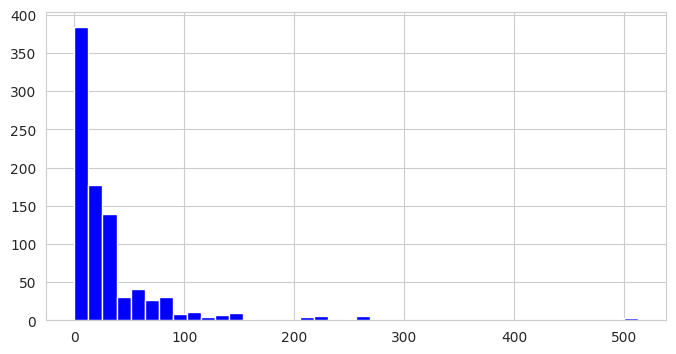

In [ ]:
train['Fare'].hist(color='blue',bins=40,figsize=(8,4))

# Cufflinks for plots

In [ ]:
import cufflinks as cf
cf.go_offline()

In [ ]:
train['Fare'].iplot(kind='hist',bins=30,color='blue')

# Data Cleaning

<ipython-input-17-98590ea6d0b5>:4: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




<Axes: xlabel='Pclass', ylabel='Age'>

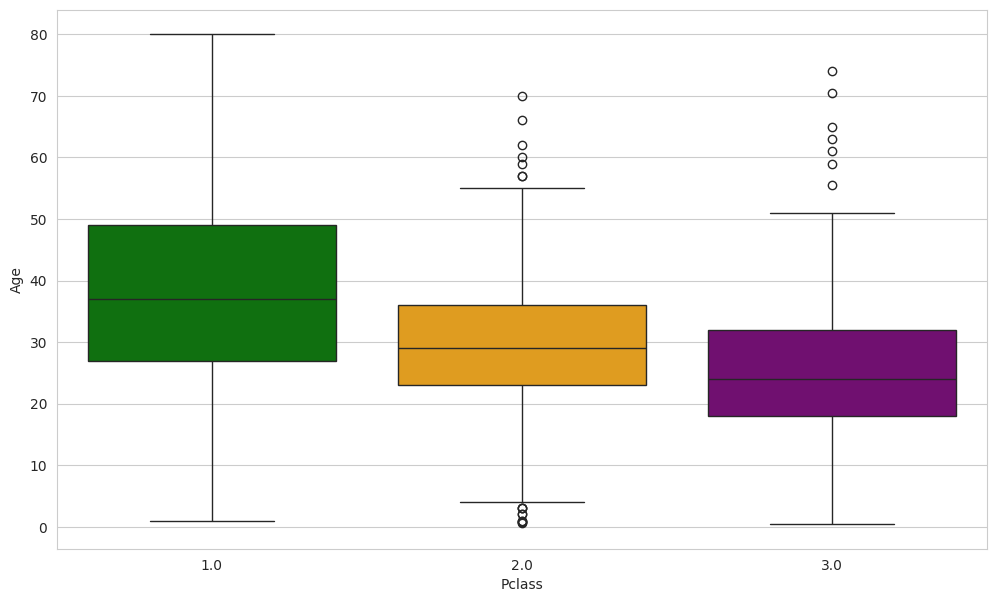

In [ ]:
palette=['green', 'orange', 'purple']

plt.figure(figsize=(12, 7))
sns.boxplot(x='Pclass', y='Age', data=train, palette=palette)

In [ ]:
def impute_age(cols):
    Age = cols[0]
    Pclass = cols[1]

    if pd.isnull(Age):

        if Pclass == 1:
            return 37

        elif Pclass == 2:
            return 29

        else:
            return 24

    else:
        return Age


In [ ]:
# Handle missing values in the 'Pclass' column by imputing with the mode
train['Pclass'].fillna(train['Pclass'].mode()[0], inplace=True)

# Handle missing values in the 'Age' column by imputing with the mean
train['Age'].fillna(train['Age'].mean(), inplace=True)

# Handle missing values in the 'Embarked' column by imputing with the mode
train['Embarked'].fillna(train['Embarked'].mode()[0], inplace=True)

# Check for missing values in the DataFrame
missing_values = train.isnull().sum()
print(missing_values)


PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Survival       0
dtype: int64


In [ ]:
# Check the column names in the DataFrame
print(train.columns)

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Embarked', 'Survival'],
      dtype='object')


<Axes: >

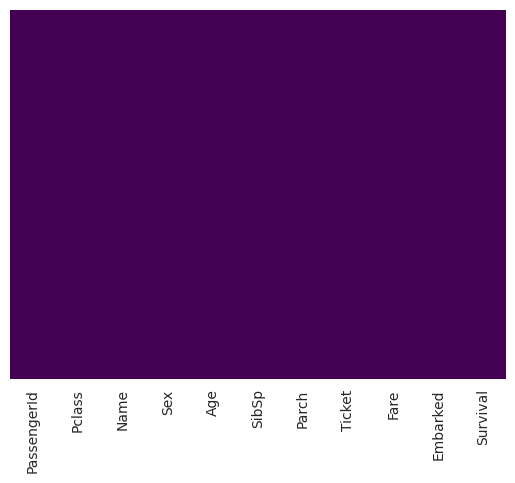

In [ ]:
sns.heatmap(train.isnull(),yticklabels=False,cbar=False,cmap='viridis')

# Converting Categorical Features (PassengerId,Pclass,Name,Sex,Age,SibSp,	Parch,Ticket,Fare,Embarked,Survival)

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 890 entries, 0 to 889
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  890 non-null    int64  
 1   Pclass       890 non-null    float64
 2   Name         890 non-null    object 
 3   Sex          890 non-null    object 
 4   Age          890 non-null    float64
 5   SibSp        890 non-null    int64  
 6   Parch        890 non-null    int64  
 7   Ticket       890 non-null    object 
 8   Fare         890 non-null    float64
 9   Embarked     890 non-null    object 
 10  Survival     890 non-null    int64  
dtypes: float64(3), int64(4), object(4)
memory usage: 76.6+ KB


# converting categorical features ('Sex' and 'Embarked') into dummy variables

In [ ]:
sex = pd.get_dummies(train['Sex'],drop_first=True)
embark = pd.get_dummies(train['Embarked'],drop_first=True)

In [ ]:
train.drop(['Sex','Embarked','Name','Ticket'],axis=1,inplace=True)

In [ ]:
train.head()

,PassengerId,Pclass,Age,SibSp,Parch,Fare,Survival
0,1,3.0,22.0,1,0,7.2500,0
1,2,1.0,38.0,1,0,71.2833,1
2,3,3.0,26.0,0,0,7.9250,1
3,4,1.0,35.0,1,0,53.1000,1
4,5,3.0,35.0,0,0,8.0500,0


In [ ]:
train = pd.concat([train,sex,embark],axis=1)


In [ ]:

train.head()

,PassengerId,Pclass,Age,SibSp,Parch,Fare,Survival,male,Q,S
0,1,3.0,22.0,1,0,7.2500,0,1,0,1
1,2,1.0,38.0,1,0,71.2833,1,0,0,0
2,3,3.0,26.0,0,0,7.9250,1,0,0,1
3,4,1.0,35.0,1,0,53.1000,1,0,0,1
4,5,3.0,35.0,0,0,8.0500,0,1,0,1


# Choosing The Best Model

**Train Test Split**

In [ ]:
train.drop('Survival',axis=1).head()

,PassengerId,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,1,3.0,22.0,1,0,7.2500,1,0,1
1,2,1.0,38.0,1,0,71.2833,0,0,0
2,3,3.0,26.0,0,0,7.9250,0,0,1
3,4,1.0,35.0,1,0,53.1000,0,0,1
4,5,3.0,35.0,0,0,8.0500,1,0,1


In [ ]:
train['Survival'].head()

0    0
1    1
2    1
3    1
4    0
Name: Survival, dtype: int64

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(train.drop('Survival', axis=1),
                                                    train['Survival'], test_size=0.2697,
                                                    random_state=101)



# Training and Predicting

# Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression


In [ ]:
logmodel = LogisticRegression()
X_train.columns = X_train.columns.astype(str)
logmodel.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



LogisticRegression()

In [ ]:
X_test.columns = X_test.columns.astype(str)
predictions = logmodel.predict(X_test)

In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
accuracy=confusion_matrix(y_test,predictions)


In [ ]:
accuracy

array([[122,  21],
       [ 37,  61]])

In [ ]:

from sklearn.metrics import accuracy_score

In [ ]:
accuracy=accuracy_score(y_test,predictions)
accuracy

0.7593360995850622

In [ ]:
predictions

array([1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0,
       0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1,
       1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0])

# Evaluation

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.77      0.85      0.81       143
           1       0.74      0.62      0.68        98

    accuracy                           0.76       241
   macro avg       0.76      0.74      0.74       241
weighted avg       0.76      0.76      0.76       241



**Hyperparameter Tuning for Logistic Regression**



In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Define the parameter grid
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}

# Instantiate the Logistic Regression model
logistic_regression = LogisticRegression(max_iter=10000, solver='lbfgs')

# Perform Grid Search Cross Validation
grid_search = GridSearchCV(logistic_regression, param_grid, cv=5, scoring='accuracy', verbose=1)
grid_search.fit(X_train, y_train)

# Get the best parameters
best_params_lr = grid_search.best_params_
print("Best Parameters for Logistic Regression:", best_params_lr)




Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Parameters for Logistic Regression: {'C': 1}


# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Instantiate the RandomForestClassifier model
randomforest = RandomForestClassifier()

# Fit the model to the training data
randomforest.fit(X_train, y_train)

# Predict on the test data
predictions = randomforest.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

# Generate confusion matrix
conf_matrix_random = confusion_matrix(y_test, predictions)
print("Confusion Matrix:\n", conf_matrix_random)

# Generate classification report
print(classification_report(y_test, predictions))



Accuracy: 0.8091286307053942
Confusion Matrix:
 [[131  12]
 [ 34  64]]
              precision    recall  f1-score   support

           0       0.79      0.92      0.85       143
           1       0.84      0.65      0.74        98

    accuracy                           0.81       241
   macro avg       0.82      0.78      0.79       241
weighted avg       0.81      0.81      0.80       241



# Hyperparameter Tuning for Random Forest

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define the parameter grid
param_grid = {'n_estimators': [100, 200, 300],
              'max_depth': [None, 10, 20, 30]}

# Instantiate the Random Forest model
random_forest = RandomForestClassifier()

# Perform Grid Search Cross Validation
grid_search = GridSearchCV(random_forest, param_grid, cv=5, scoring='accuracy', verbose=1)
grid_search.fit(X_train, y_train)

# Get the best parameters
best_params_rf = grid_search.best_params_
print("Best Parameters for Random Forest:", best_params_rf)


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Parameters for Random Forest: {'max_depth': 10, 'n_estimators': 100}


# SVM Model

In [ ]:
from sklearn.svm import SVC

# Initialize SVM Classification model
svm_classifier = SVC()

# Fit the SVM Classification model to the training data
svm_classifier.fit(X_train, y_train)

# Predict on the test data using SVM Classification model
svm_predictions = svm_classifier.predict(X_test)

# Calculate accuracy for SVM Classification model
svm_accuracy = accuracy_score(y_test, svm_predictions)
print("\nSVM Classification Accuracy:", svm_accuracy)

# Generate confusion matrix for SVM Classification model
conf_matrix_svm = confusion_matrix(y_test, svm_predictions)
print("SVM Classification Confusion Matrix:\n", conf_matrix_svm)

# Generate classification report for SVM Classification model
print("SVM Classification Report:")
print(classification_report(y_test, svm_predictions))



SVM Classification Accuracy: 0.6224066390041494
SVM Classification Confusion Matrix:
 [[139   4]
 [ 87  11]]
SVM Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.97      0.75       143
           1       0.73      0.11      0.19        98

    accuracy                           0.62       241
   macro avg       0.67      0.54      0.47       241
weighted avg       0.66      0.62      0.53       241



# Hyperparameter Tuning for SVM

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

# Define the parameter grid
param_grid = {'C': [0.1, 1, 10, 100],
              'kernel': ['linear', 'rbf', 'poly', 'sigmoid']}

# Instantiate the SVM model
svm_classifier = SVC()

# Perform Grid Search Cross Validation
grid_search = GridSearchCV(svm_classifier, param_grid, cv=5, scoring='accuracy', verbose=1)
grid_search.fit(X_train, y_train)

# Get the best parameters
best_params_svm = grid_search.best_params_
print("Best Parameters for SVM:", best_params_svm)


Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Parameters for SVM: {'C': 100, 'kernel': 'linear'}


# California Price Prediction

# Dataset Collection

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

In [ ]:
# Step 1: Load the dataset
file_path = "/content/drive/MyDrive/data/housing_coursework_entire_dataset_23-24.csv"
df = pd.read_csv(file_path)

In [ ]:
# Step 2: Display the first 5 rows
print("First 5 rows of the dataset:")
print(df.head())

First 5 rows of the dataset:
   No.  longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    1    -122.12     37.70                  17         2488           617.0   
1    2    -122.21     38.10                  36         3018           557.0   
2    3    -122.22     38.11                  43         1939           353.0   
3    4    -122.20     37.78                  52         2300           443.0   
4    5    -122.19     37.79                  50          954           217.0   

   population  households  median_income  median_house_value ocean_proximity  
0        1287         538         2.9922              179900        NEAR BAY  
1        1445         556         3.8029              129900        NEAR BAY  
2         968         392         3.1848              112700        NEAR BAY  
3        1225         423         3.5398              158400        NEAR BAY  
4         546         201         2.6667              172800        NEAR BAY  


# Data Preprocessing

In [ ]:
# Step 3: Check and display null values
print("\nNull values in the dataset:")
print(df.isnull().sum())


Null values in the dataset:
No.                   0
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        9
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       2
dtype: int64


In [ ]:
# Step 5: Handle missing values by imputing with median and mode
# Handling missing values for numerical features with median
numerical_imputer = SimpleImputer(strategy='median')
df['total_bedrooms'] = numerical_imputer.fit_transform(df[['total_bedrooms']])

# Handling missing values for categorical feature with mode
categorical_imputer = SimpleImputer(strategy='most_frequent')
df['ocean_proximity'] = categorical_imputer.fit_transform(df[['ocean_proximity']])

# Check if missing values have been handled
print("\nAfter handling missing values:")
print(df.isnull().sum())



After handling missing values:
No.                   0
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


In [ ]:
# Step 4: Plotting function
def plot_feature_distribution(df, feature):
    plt.figure(figsize=(8, 6))
    plt.hist(df[feature], bins=30, color='blue', alpha=0.7)
    plt.title(f'Distribution of {feature}', fontsize=15)
    plt.xlabel(feature, fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.grid(True)
    plt.show()

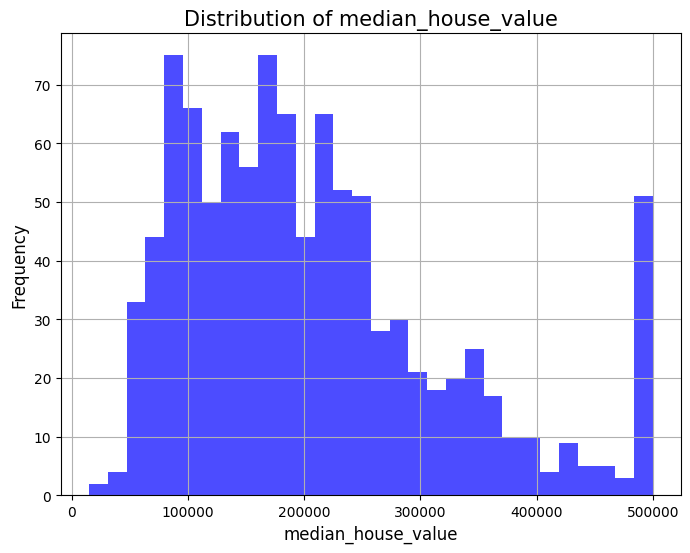

In [ ]:
# Example usage of the plotting function
plot_feature_distribution(df, 'median_house_value')

In [ ]:
# Step 6: One-hot encode categorical features
# Identify categorical features
categorical_features = ['ocean_proximity']

# Perform one-hot encoding
encoder = OneHotEncoder(handle_unknown='ignore', sparse=False)
encoded_features = encoder.fit_transform(df[categorical_features])

# Create a DataFrame with one-hot encoded features
encoded_features_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(categorical_features))

# Concatenate the one-hot encoded features with the original dataframe
df_encoded = pd.concat([df.drop(columns=categorical_features), encoded_features_df], axis=1)


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [ ]:
# Check if 'ocean_proximity' column exists in the DataFrame
if 'ocean_proximity' in df.columns:
    # Perform one-hot encoding
    encoder = OneHotEncoder(handle_unknown='ignore', sparse=False)
    encoded_features = encoder.fit_transform(df[categorical_features])

    # Create a DataFrame with one-hot encoded features
    encoded_features_df = pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(categorical_features))

    # Concatenate the one-hot encoded features with the original dataframe
    df_encoded = pd.concat([df.drop(columns=categorical_features), encoded_features_df], axis=1)
else:
    print("Error: 'ocean_proximity' column not found in the DataFrame.")


/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [ ]:
# Step 1: One-hot encode categorical feature 'ocean_proximity'
encoder = OneHotEncoder(sparse=False)
ocean_proximity_encoded = encoder.fit_transform(df[['ocean_proximity']])
ocean_proximity_encoded_df = pd.DataFrame(ocean_proximity_encoded, columns=encoder.categories_[0], index=df.index)
df = pd.concat([df, ocean_proximity_encoded_df], axis=1)
df.drop(columns=['ocean_proximity'], inplace=True)

/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


# Splitting the Dataset

In [ ]:
# Step 2: Split the data into features and target
X = df.drop(columns=['median_house_value'])  # Features (all columns except 'median_house_value')
y = df['median_house_value']  # Target (only 'median_house_value')

In [ ]:
# Step 3: Split the data into train (800 points) and test (200 points)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Step 4: Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Step 5: Display sizes of train and test sets
print("Size of training set:", len(X_train))
print("Size of testing set:", len(X_test))

Size of training set: 800
Size of testing set: 200


# Building the Model

**Random Forest Model**

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import numpy as np

# Initialize Random Forest model
random_forest_model = RandomForestRegressor(random_state=42)

# Fit the Random Forest model
random_forest_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = random_forest_model.predict(X_test)

# Evaluate the Random Forest model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)

# Print evaluation metrics
print("Random Forest Model:")
print(f"MAE: {mae_rf}")
print(f"R-squared: {r2_rf}")
print(f"MSE: {mse_rf}")
print(f"RMSE: {rmse_rf}")


Random Forest Model:
MAE: 42747.2909
R-squared: 0.7116539927556917
MSE: 3515634201.657189
RMSE: 59292.78372329291


**Gradient Boosting Model**

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import numpy as np

# Initialize Gradient Boosting model
gradient_boosting_model = GradientBoostingRegressor(random_state=42)

# Fit the Gradient Boosting model
gradient_boosting_model.fit(X_train, y_train)

# Make predictions
y_pred_gb = gradient_boosting_model.predict(X_test)

# Evaluate the Gradient Boosting model
mae_gb = mean_absolute_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)
mse_gb = mean_squared_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mse_gb)

# Print evaluation metrics
print("Gradient Boosting Model:")
print(f"MAE: {mae_gb}")
print(f"R-squared: {r2_gb}")
print(f"MSE: {mse_gb}")
print(f"RMSE: {rmse_gb}")


Gradient Boosting Model:
MAE: 41484.81742075734
R-squared: 0.7465546048418179
MSE: 3090111453.2017317
RMSE: 55588.77092724512


In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import numpy as np

# Initialize Decision Tree model
decision_tree_model = DecisionTreeRegressor(random_state=42)

# Fit the Decision Tree model
decision_tree_model.fit(X_train, y_train)

# Make predictions
y_pred_dt = decision_tree_model.predict(X_test)

# Evaluate the Decision Tree model
mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)
mse_dt = mean_squared_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mse_dt)

# Print evaluation metrics
print("Decision Tree Model:")
print(f"MAE: {mae_dt}")
print(f"R-squared: {r2_dt}")
print(f"MSE: {mse_dt}")
print(f"RMSE: {rmse_dt}")


Decision Tree Model:
MAE: 53463.515
R-squared: 0.4967726374920771
MSE: 6135556874.015
RMSE: 78329.79556985325


# Fine tunning

**Random Forest **

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# Random Forest Regressor
random_forest_reg = RandomForestRegressor(random_state=42)

# Define grid of parameters to search
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt']
}

# GridSearchCV to find the best hyperparameters
grid_search = GridSearchCV(random_forest_reg, param_grid, cv=5, scoring='r2', return_train_score=True)
grid_search.fit(X_train_scaled, y_train)

# Best parameters and R2 score
print("Best parameters:", grid_search.best_params_)
print("Best R2 score:", grid_search.best_score_)


/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:413: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0` or remove this parameter as it is also the default value for RandomForestRegressors and ExtraTreesRegressors.
  warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:413: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0` or remove this parameter as it is also the default value for RandomForestRegressors and ExtraTreesRegressors.
  warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_forest.py:413: FutureWarning: `max_features='auto'` has been deprecated in 1.1 and will be removed in 1.3. To keep the past behaviour, explicitly set `max_features=1.0` or remove this parameter as it is also the default value for RandomForestRegressors

KeyboardInterrupt: 

**Gradient Boosting **

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor

# Gradient Boosting Regressor
gradient_boost_reg = GradientBoostingRegressor(random_state=42)

# Define grid of parameters to search
param_grid = {
    'n_estimators': [50, 100, 150],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}

# GridSearchCV to find the best hyperparameters
grid_search = GridSearchCV(gradient_boost_reg, param_grid, cv=5, scoring='r2', return_train_score=True)
grid_search.fit(X_train_scaled, y_train)

# Best parameters and R2 score
print("Best parameters:", grid_search.best_params_)
print("Best R2 score:", grid_search.best_score_)


**Decision Tree**

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor

# Decision Tree Regressor
tree_reg = DecisionTreeRegressor(random_state=42)

# Define grid of parameters to search
param_grid = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10]
}

# GridSearchCV to find the best hyperparameters
grid_search = GridSearchCV(tree_reg, param_grid, cv=5, scoring='r2', return_train_score=True)
grid_search.fit(X_train_scaled, y_train)

# Best parameters and R2 score
print("Best parameters:", grid_search.best_params_)
print("Best R2 score:", grid_search.best_score_)


Best parameters: {'max_depth': None, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best R2 score: 0.5207787382912401


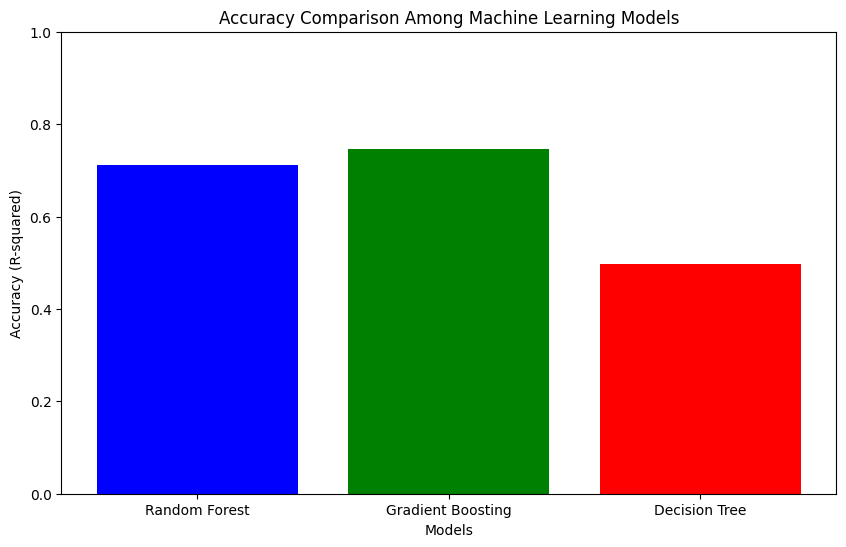

In [ ]:
import matplotlib.pyplot as plt

# Accuracy values for each model
models = ["Random Forest", "Gradient Boosting", "Decision Tree"]
accuracy = [0.7117, 0.7466, 0.4968]  # R-squared values as accuracy percentages

# Plotting the graph
plt.figure(figsize=(10, 6))
plt.bar(models, accuracy, color=['blue', 'green', 'red'])
plt.xlabel('Models')
plt.ylabel('Accuracy (R-squared)')
plt.title('Accuracy Comparison Among Machine Learning Models')
plt.ylim(0, 1)  # Set the y-axis limit to the range of accuracy values
plt.show()


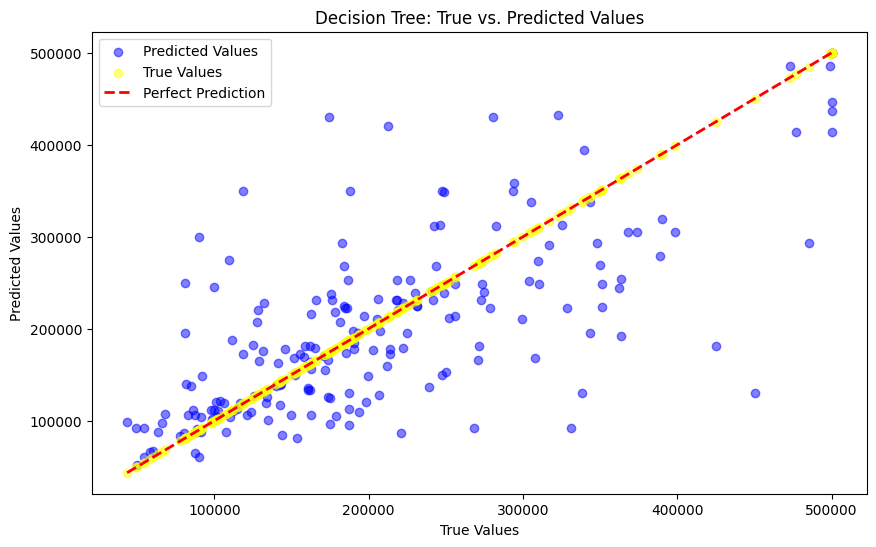

In [ ]:
from sklearn.tree import DecisionTreeRegressor

# Initialize and train the Decision Tree model
tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(X_train_scaled, y_train)

# Predicted values for Decision Tree model
pred_tree = tree_reg.predict(X_test_scaled)

# Plotting the true vs. predicted values for Decision Tree model
plt.figure(figsize=(10, 6))
plt.scatter(y_test, pred_tree, color='blue', alpha=0.5, label='Predicted Values')
plt.scatter(y_test, y_test, color='yellow', alpha=0.5, label='True Values')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('Decision Tree: True vs. Predicted Values')
plt.legend()
plt.show()




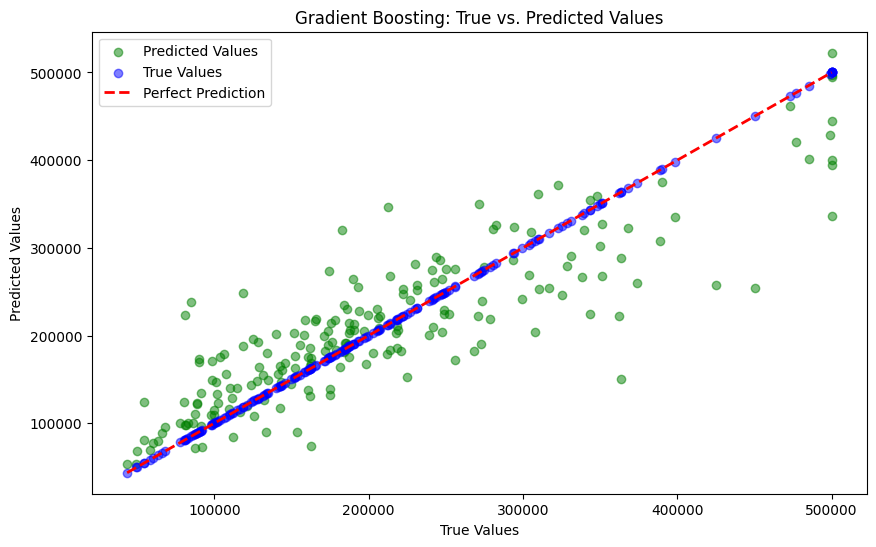

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

# Initialize and train the Gradient Boosting model
gradient_boosting_model = GradientBoostingRegressor(random_state=42)
gradient_boosting_model.fit(X_train_scaled, y_train)

# Predicted values for Gradient Boosting model
pred_gradient_boost = gradient_boosting_model.predict(X_test_scaled)

# Plotting the true vs. predicted values for Gradient Boosting model
plt.figure(figsize=(10, 6))
plt.scatter(y_test, pred_gradient_boost, color='green', alpha=0.5, label='Predicted Values')  # Predicted values in green
plt.scatter(y_test, y_test, color='blue', alpha=0.5, label='True Values')  # True values in blue
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('Gradient Boosting: True vs. Predicted Values')
plt.legend()
plt.show()



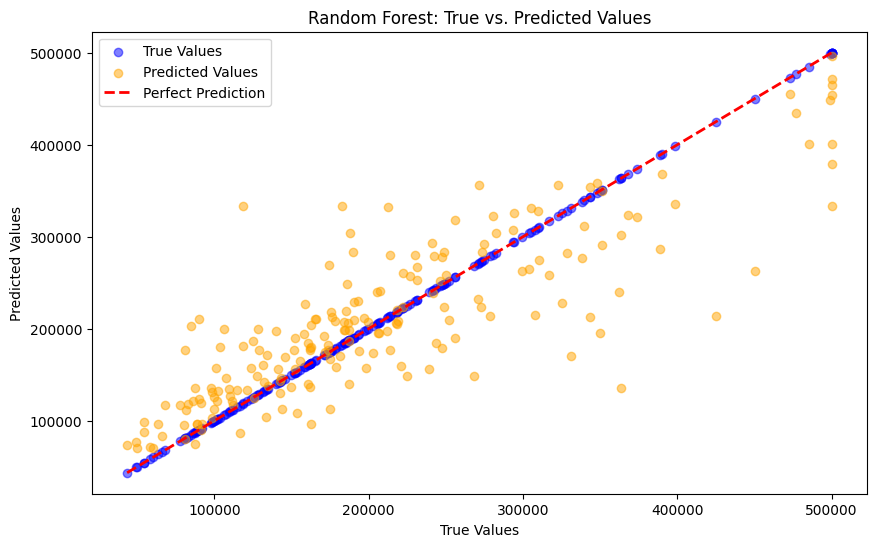

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train the Random Forest model
random_forest_model = RandomForestRegressor(random_state=42)
random_forest_model.fit(X_train_scaled, y_train)

# Predicted values for Random Forest model
pred_random_forest = random_forest_model.predict(X_test_scaled)

# Plotting the true vs. predicted values for Random Forest model
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test, color='blue', alpha=0.5, label='True Values')  # True values in blue
plt.scatter(y_test, pred_random_forest, color='orange', alpha=0.5, label='Predicted Values')  # Predicted values in orange
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('Random Forest: True vs. Predicted Values')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')
plt.legend()
plt.show()



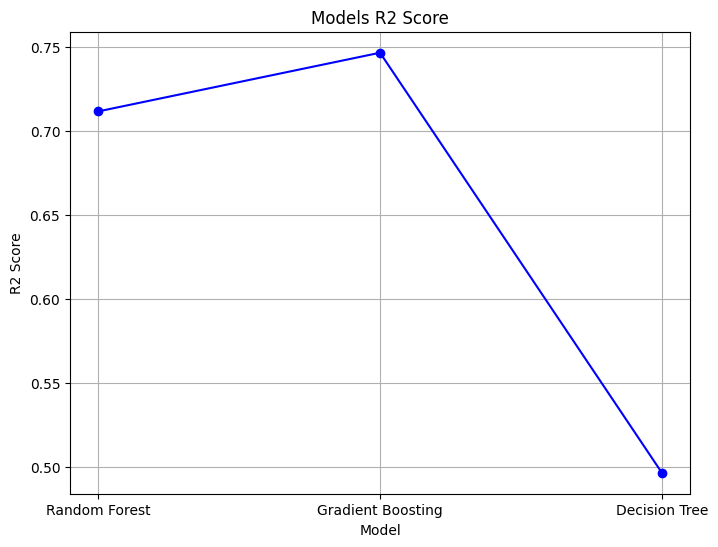

In [ ]:
import matplotlib.pyplot as plt

# Models and their corresponding R-squared scores
models = ['Random Forest', 'Gradient Boosting', 'Decision Tree']
r_squared = [0.7117, 0.7466, 0.4968]

# Plotting the R-squared scores
plt.figure(figsize=(8, 6))
plt.plot(models, r_squared, marker='o', linestyle='-', color='b')
plt.title('Models R2 Score')
plt.xlabel('Model')
plt.ylabel('R2 Score')
plt.grid(True)
plt.show()
